In [45]:
import dataset
import importlib
from pathlib import Path

importlib.reload(dataset)

path: str=Path(r"F:/Python/SAM2/OCTDatasetOIMHS")
participants = ["1", "2"] #  os.listdir(path / "Images")
dat = dataset.OIMHSDataset(participants, path)



In [46]:
dat[0]

Flip


(tensor([[[-0.7587, -0.7587, -0.7587,  ..., -0.7587, -0.7587, -0.7587],
          [-0.7587, -0.7587, -0.7587,  ..., -0.7587, -0.7587, -0.7587],
          [-0.7587, -0.7587, -0.7587,  ..., -0.7587, -0.7587, -0.7587],
          ...,
          [ 0.0308, -0.3264, -0.4768,  ..., -0.5896, -0.4580, -0.4204],
          [-0.1572, -0.1760, -0.3640,  ..., -0.5708, -0.6084, -0.7587],
          [-0.4204, -0.2700, -0.3640,  ..., -0.7023, -0.7587, -0.7587]]]),
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]))

Flip


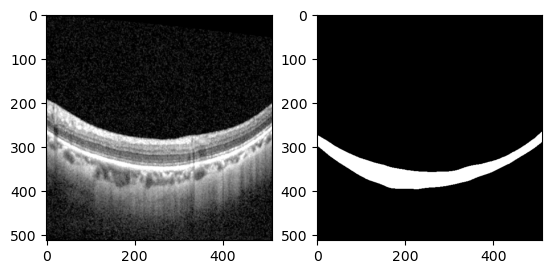

In [47]:
import matplotlib.pyplot as plt

te = dat[20]

fig, ax = plt.subplots(1, 2)
ax[0].imshow(te[0][0], cmap="gray")
ax[1].imshow(te[1][0], cmap="gray")
plt.show()

(512, 512, 3)


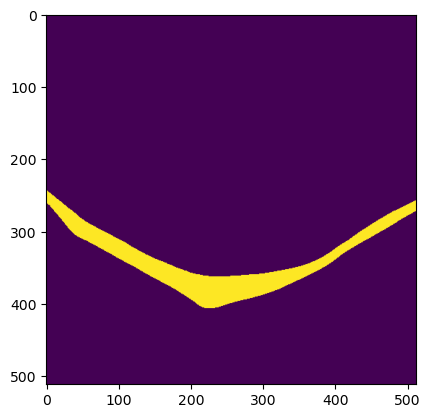

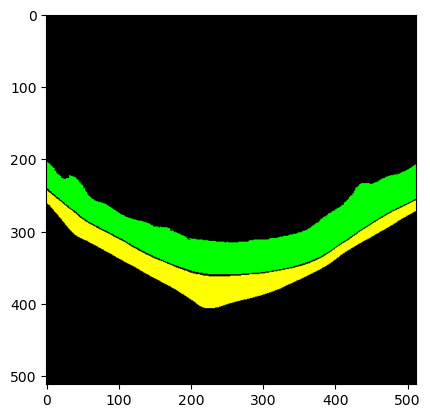

In [44]:
from PIL import Image
import numpy as np
test_path = Path(r"F:/Python/SAM2/OCTDatasetOIMHS/Annotations/1/1.png")
test_image = Image.open(test_path)
arr_img = np.array(test_image, dtype=np.uint8)
arr_mask = ((arr_img[:, :, 0] == 255) & (arr_img[:, :, 1] == 255) & (arr_img[:, :, 2] == 0)).astype(np.uint8)
print(arr_img.shape)
plt.imshow(arr_mask)
plt.show()
plt.imshow(arr_img)
plt.show()



In [51]:
import dataset
import importlib
from pathlib import Path
import os

importlib.reload(dataset)

path: str=Path(r"F:/Python/SAM2/OCTDatasetOIMHS")
participants = os.listdir(path / "Images")

print(participants)

train_loader, test_loader = dataset.get_dataloader(participants,
                                                   batch_size=32,
                                                   num_workers=0)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
x, y = next(iter(test_loader))
print(x.shape, y.shape)

['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
torch.Size([32, 1, 512, 512]) torch.Size([32, 1, 512, 512])
torch.Size([32, 1, 512, 512]) torch.Size([32, 1, 512, 512])


In [7]:
import model
import importlib
importlib.reload(model)

myModel = model.build_smp_model(arch="unet++", encoder_name="resnet50", encoder_weights="ssl")

print(myModel.encoder)

import torch


# random torch tensor
x = torch.rand((2, 1, 512, 512))
y = myModel.encoder(x)
print(y[0].shape)

ResNetEncoder(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (

In [12]:
print(myModel.encoder)



ResNetEncoder(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (

In [13]:
import segmentation_models_pytorch as smp

encoder = smp.encoders.get_encoder(
    "resnet50",
    in_channels=1,
    weights=None,
)
print(encoder)

ResNetEncoder(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (

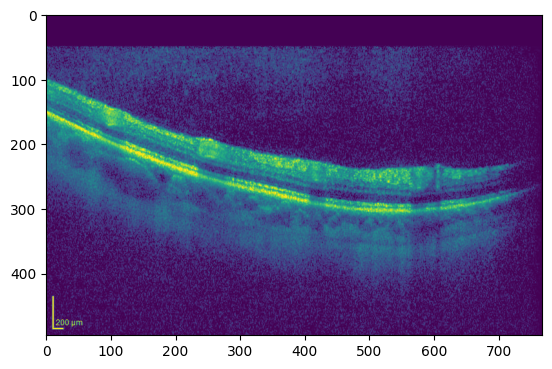

torch.Size([1, 1, 512, 512])


In [21]:
from PIL import Image

img = Image.open(r"datasets/OCTDatasetNormalDrusenCNV/Images/NORMAL/1/OD/000_normal.jpg")
img = img.convert("L")  # convert to grayscale
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

import segmentation_models_pytorch as smp

encoder = smp.encoders.get_encoder(
    "resnet34",
    in_channels=1,
    weights=None,
)

import numpy as np
img_np = np.array(img, dtype=np.float32) 

import torch

img_tensor = torch.tensor(img_np).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
img_tensor = img_tensor.resize_(1, 1, 512, 512)  # resize to (1, 1, 512, 512)
features = encoder(img_tensor)
print(features[0].shape)

In [32]:
import torch

size = (512, 512)
input_tensor = torch.randn((1, 1) + size)
print(input_tensor.shape)

torch.Size([1, 1, 512, 512])


In [27]:

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.encoders import get_encoder, get_encoder_names
import pandas as pd

def count_params(model):
    return sum(p.numel() for p in model.parameters())


results = []

for name in get_encoder_names():
    try:
        encoder = get_encoder(name, pretrained=None)
        params = sum(p.numel() for p in encoder.parameters())
        results.append({"encoder": name, "params": params, "note": ""})
    except Exception as e:
        results.append({"encoder": name, "params": -1, "note": str(e)})

# sortiert nach Größe
df = pd.DataFrame(results)
df = df.sort_values("params", ascending=False)
display(df)



,encoder,params,note
10,resnext101_32x48d,826362176,
56,timm-efficientnet-l2,474804308,
9,resnext101_32x32d,466481472,
8,resnext101_32x16d,191977792,
25,senet154,113039984,
...,...,...,...
47,timm-efficientnet-b0,4007548,
72,mobileone_s1,3544192,
57,timm-tf_efficientnet_lite0,3371008,
65,mit_b0,3319392,


In [31]:
df.loc[df["params"] < (22 * 1e6)].sort_values("encoder")

,encoder,params,note
31,densenet121,6953856,
32,densenet169,12484480,
33,densenet201,18092928,
11,dpn68,11778602,
12,dpn68b,11778602,
37,efficientnet-b0,4007548,
38,efficientnet-b1,6513184,
39,efficientnet-b2,7700994,
40,efficientnet-b3,10696232,
41,efficientnet-b4,17548616,
